In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis_helper import (
    calculate_diversity_ratio,
    calculate_bias_metrics,
    DataAnalysisPipeline,
)
from analysis_plot import (
    plot_knee,
    plot_batch_metric_violins,
    analyze_batch_statistics,
    plot_bias_correlations,
    plot_hc_variance_and_heatmap,
    plot_hc_pca_grid,
    check_batch_classification_power,
    check_bias_power_dist,
    plot_model_auc_grid,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

### Covariate Multicollinearity (VIF)

In [4]:
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor

from config import BIAS_COLUMNS

# QC/bias metrics not currently used as model covariates (BIAS_COLUMNS).
# umi_tools-* excluded: only 13.5% coverage (tool not run for most batches).
EXTRA_CANDIDATES = [
    "NP80",
    "picard_mark_duplicates-PERCENT_DUPLICATION",
    "samtools_stats-error_rate",
    "samtools_stats-reads_mapped_percent",
    "samtools_stats-reads_properly_paired_percent",
    "samtools_stats-reads_MQ0_percent",
    "samtools_stats-insert_size_average",
    "salmon-percent_mapped",
    "star-mapped_percent",
    "star-uniquely_mapped_percent",
    "fastp-pct_duplication",
    "fastp-after_filtering_q30_rate",
    "fastp-after_filtering_gc_content",
    "fastp-pct_surviving",
    "fastp-pct_adapter",
    "cds_exons_tag_pct",
    "5_utr_exons_tag_pct",
    "3_utr_exons_tag_pct",
    "introns_tag_pct",
    "tss_up_1kb_tag_pct",
    "tes_down_1kb_tag_pct",
    "other_intergenic_tag_pct",
    "Total Centrifugation Force (g)",
    "Sample Volume (mL)",
]
VIF_CSV = "./Analysis_Results/vif_covariate_candidates.csv"


def compute_vif(df):
    X = df.assign(const=1.0).values
    vifs = [variance_inflation_factor(X, i) for i in range(df.shape[1])]
    return pd.Series(vifs, index=df.columns).sort_values(ascending=False)


df_vif = adata.obs[BIAS_COLUMNS + EXTRA_CANDIDATES].apply(pd.to_numeric, errors="coerce").dropna()
df_vif = df_vif.drop(columns=df_vif.columns[df_vif.std() == 0])
print(f"Complete-case n = {len(df_vif)} / {len(adata.obs)} ({100 * len(df_vif) / len(adata.obs):.1f}%)")

if os.path.isfile(VIF_CSV):
    vif_result = pd.read_csv(VIF_CSV, index_col=0)
else:
    vif_result = pd.concat([
        compute_vif(df_vif[BIAS_COLUMNS]).rename("VIF_current_10_only"),
        compute_vif(df_vif).rename("VIF_with_extra_candidates"),
    ], axis=1)
    vif_result["group"] = ["current_10" if c in BIAS_COLUMNS else "extra_candidate" for c in vif_result.index]
    vif_result = vif_result.sort_values("VIF_with_extra_candidates", ascending=False)
    vif_result.to_csv(VIF_CSV)

vif_result[vif_result["group"] == "current_10"].sort_values("VIF_current_10_only", ascending=False)

Complete-case n = 2768 / 3209 (86.3%)


,VIF_current_10_only,VIF_with_extra_candidates,group
NG80,4.057934,115.058725,current_10
Spliced Reads (%),3.496650,12.552322,current_10
(NP80/NG80),2.511623,3.640977,current_10
Gene Length Bias,2.371678,4.832385,current_10
gDNA Contamination (Intron/Exon),2.250000,16.877236,current_10
GC Bias,2.228465,2.981754,current_10
RNA Degradation (3' Bias),2.120470,84.889451,current_10
rRNA Fraction,1.663328,4.949731,current_10
Platelet Score,1.613008,2.355773,current_10
log(Total Reads),1.450066,3.597011,current_10


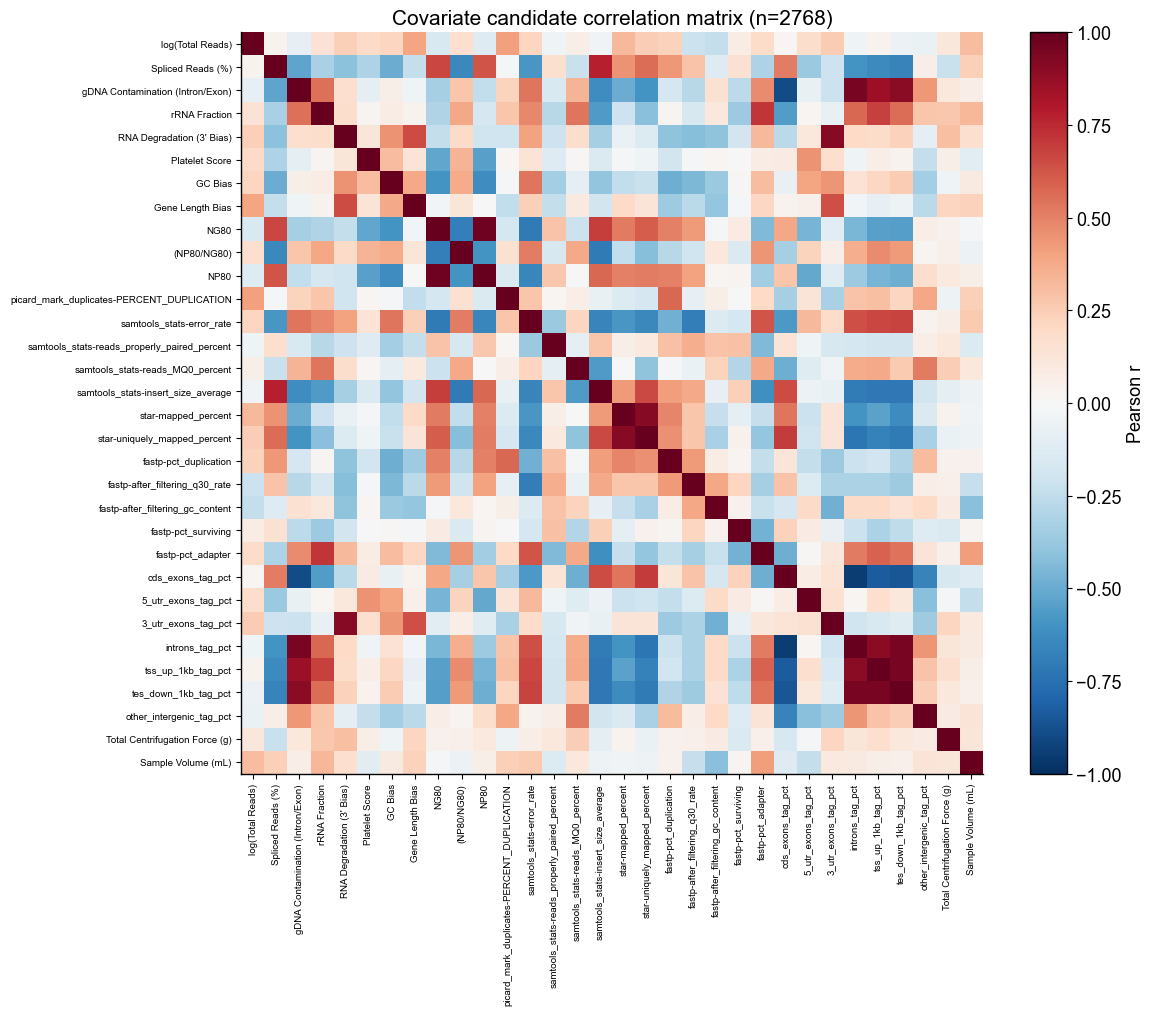

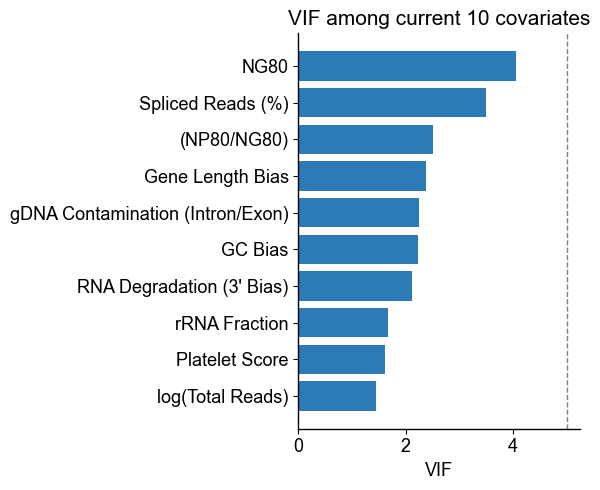

In [5]:
corr = df_vif.corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title(f"Covariate candidate correlation matrix (n={len(df_vif)})")
fig.tight_layout()
# fig.savefig("./Analysis_Results/vif_covariate_candidates.png")

vif_current = vif_result.loc[BIAS_COLUMNS, "VIF_current_10_only"].sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(vif_current.index, vif_current.values,
        color=["#c0392b" if v >= 5 else "#2c7bb6" for v in vif_current.values])
ax.axvline(5, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("VIF")
ax.set_title("VIF among current 10 covariates")
fig.tight_layout()
# fig.savefig("./Analysis_Results/vif_current_10.png")